In [16]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split

with open("style_descriptions.json", encoding="utf-8") as f:
    desc = json.load(f)

labels = pd.read_csv("house_images/labels.csv")
labels.columns = ["filename", "label"]
labels["text"] = labels["filename"].map(desc)
labels = labels.dropna(subset=["text"]).reset_index(drop=True)

parts = []
for cls in labels["label"].unique():
    sub = labels[labels["label"] == cls]
    parts.append(sub.sample(n=75, random_state=42))
balanced = pd.concat(parts, ignore_index=True)

main, best = train_test_split(
    balanced,
    test_size=2/3,
    stratify=balanced["label"],
    random_state=42,
)
main = main.reset_index(drop=True)
best = best.reset_index(drop=True)

main.to_csv("main_set.csv", index=False)
best.to_csv("best_set.csv", index=False)

print("main_set:", len(main))
print(main["label"].value_counts().to_string())
print("\nbest_set:", len(best))
print(best["label"].value_counts().to_string())

main_set: 75
label
rustic       25
farmhouse    25
modern       25

best_set: 150
label
farmhouse    50
modern       50
rustic       50


In [6]:
import os
import base64
import time
from io import BytesIO
from PIL import Image
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.environ["ROUTERAI_KEY"],
    base_url="https://routerai.ru/api/v1",
)

def encode_image(path, max_size=512):
    img = Image.open(path).convert("RGB")
    img.thumbnail((max_size, max_size))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

IMG_PATH = "house_images/all_images/all_images/243_6a3aad07.jpg"
PROMPT = "Look at the house. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"

MODELS = [
    "openai/gpt-6-luna",
    "qwen/qwen3.8-omni-flash",
    "mistralai/mistral-medium-3.1",
]

b64 = encode_image(IMG_PATH)

for model in MODELS:
    print(f"\n=== {model} ===")
    t0 = time.time()
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image_url",
                     "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
                    {"type": "text", "text": PROMPT},
                ],
            }],
            max_tokens=20,
            temperature=0,
            extra_body={"reasoning": {"enabled": False}},
        )
        latency = time.time() - t0
        print("Ответ:        ", resp.choices[0].message.content)
        print("Токены (вх):  ", resp.usage.prompt_tokens)
        print("Токены (вых): ", resp.usage.completion_tokens)
        print(f"Latency:       {latency:.2f} с")
        print("Стоимость:    ", getattr(resp.usage, "cost", "n/a"))
    except Exception as e:
        print("Ошибка:", type(e).__name__, e)


=== openai/gpt-6-luna ===
Ответ:         farmhouse
Токены (вх):   287
Токены (вых):  6
Latency:       1.78 с
Стоимость:     0.003520046933

=== qwen/qwen3.8-omni-flash ===
Ответ:         farmhouse
Токены (вх):   253
Токены (вых):  3
Latency:       1.79 с
Стоимость:     0.0043706324064

=== mistralai/mistral-medium-3.1 ===
Ответ:         farmhouse
Токены (вх):   352
Токены (вых):  4
Latency:       0.76 с
Стоимость:     0.016523122512000003


In [17]:
import os, re, json, time, base64
from io import BytesIO
from PIL import Image
import pandas as pd
import numpy as np
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from tqdm.auto import tqdm

load_dotenv()

client = OpenAI(
    api_key=os.environ["ROUTERAI_KEY"],
    base_url="https://routerai.ru/api/v1",
)

CLASSES = ["rustic", "farmhouse", "modern"]
IMG_DIR = "house_images/all_images/all_images"

PROMPT_IMG = "Look at the house. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"
PROMPT_TXT = "Classify the architectural style based on this description. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"
PROMPT_MUL = "Look at the house and its description. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"

MODELS = [
    "openai/gpt-6-luna",
    "deepseek/deepseek-v4.1-flash",
    "mistralai/mistral-medium-3.1",
]

def encode(path, max_size=512):
    img = Image.open(path).convert("RGB")
    img.thumbnail((max_size, max_size))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def parse(text):
    if not text:
        return None
    t = text.lower()
    for c in CLASSES:
        if c in t:
            return c
    return None

def call(model, content):
    t0 = time.time()
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": content}],
            max_tokens=20,
            temperature=0,
            extra_body={"reasoning": {"enabled": False}},
        )
        latency = time.time() - t0
        cost = getattr(resp.usage, "cost", 0) or 0
        return parse(resp.choices[0].message.content), latency, cost
    except Exception as e:
        print(f"  error {model}: {e}")
        return None, time.time() - t0, 0.0

# ---- загрузка main_set ----
main = pd.read_csv("main_set.csv")
print("main_set:", len(main))
print(main["label"].value_counts().to_string())

# ---- прогон по каждой модели ----
all_summaries = []

for model in MODELS:
    print(f"\n{'='*60}\n{model}\n{'='*60}")

    y_true = []
    y = {"text": [], "image": [], "multimodal": []}
    invalid = {"text": 0, "image": 0, "multimodal": 0}
    lat = {"text": [], "image": [], "multimodal": []}
    cost = {"text": 0.0, "image": 0.0, "multimodal": 0.0}

    for _, row in tqdm(main.iterrows(), total=len(main), desc=model.split("/")[-1]):
        path = os.path.join(IMG_DIR, row["filename"])
        if not os.path.exists(path):
            continue
        b64 = encode(path)
        text = str(row["text"])
        y_true.append(row["label"])

        # text-only
        p, lt, c = call(model, [
            {"type": "text", "text": f'Description: "{text}"\n{PROMPT_TXT}'}
        ])
        if p is None: invalid["text"] += 1
        y["text"].append(p or "farmhouse"); lat["text"].append(lt); cost["text"] += c

        # image-only
        p, lt, c = call(model, [
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            {"type": "text", "text": PROMPT_IMG},
        ])
        if p is None: invalid["image"] += 1
        y["image"].append(p or "farmhouse"); lat["image"].append(lt); cost["image"] += c

        # multimodal
        p, lt, c = call(model, [
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            {"type": "text", "text": f'Description: "{text}"\n{PROMPT_MUL}'},
        ])
        if p is None: invalid["multimodal"] += 1
        y["multimodal"].append(p or "farmhouse"); lat["multimodal"].append(lt); cost["multimodal"] += c

    # метрики
    def metrics(yt, yp):
        return (
            round(accuracy_score(yt, yp), 4),
            round(f1_score(yt, yp, average="macro", zero_division=0), 4),
            round(matthews_corrcoef(yt, yp), 4),
        )

    for mode in ["text", "image", "multimodal"]:
        a, f, m = metrics(y_true, y[mode])
        inv = invalid[mode] / len(y_true)
        lt_avg = round(np.mean(lat[mode]), 3)
        lt_p95 = round(np.percentile(lat[mode], 95), 3)
        print(f"  {mode:11s} acc={a}  F1={f}  MCC={m}  inv={inv:.3f}  "
              f"lat_avg={lt_avg}s  lat_p95={lt_p95}s  cost={cost[mode]:.4f}")
        all_summaries.append({
            "model": model,
            "mode": mode,
            "accuracy": a,
            "macro_f1": f,
            "mcc": m,
            "invalid_rate": round(inv, 4),
            "lat_avg": lt_avg,
            "lat_p95": lt_p95,
            "cost_total": round(cost[mode], 4),
        })

    # сохраняем предсказания по модели
    pd.DataFrame({
        "filename": main["filename"].iloc[:len(y_true)],
        "true": y_true,
        "text_pred": y["text"],
        "image_pred": y["image"],
        "multimodal_pred": y["multimodal"],
    }).to_csv(f"preds_main_{model.replace('/', '_')}.csv", index=False)

# ---- сводка ----
df = pd.DataFrame(all_summaries)
df.to_csv("summary_main.csv", index=False)

print("\n" + "=" * 80)
print("ИТОГОВАЯ СВОДКА")
print("=" * 80)
print(df.to_string(index=False))
print(f"\nОбщая стоимость: ~{df['cost_total'].sum():.3f} ₽")

# ---- приросты ----
print("\n" + "=" * 80)
print("ПРИРОСТ MULTIMODAL НАД UNIMODAL BASELINE")
print("=" * 80)
for model in MODELS:
    sub = df[df["model"] == model].set_index("mode")
    f_text = sub.loc["text", "macro_f1"]
    f_img = sub.loc["image", "macro_f1"]
    f_mul = sub.loc["multimodal", "macro_f1"]
    best_base = max(f_text, f_img)
    print(f"{model:35s}  +Δ vs text={f_mul - f_text:+.4f}  "
          f"+Δ vs image={f_mul - f_img:+.4f}  "
          f"+Δ vs best baseline={f_mul - best_base:+.4f}")

main_set: 75
label
rustic       25
farmhouse    25
modern       25

openai/gpt-6-luna


gpt-6-luna:   0%|          | 0/75 [00:00<?, ?it/s]

  text        acc=0.8667  F1=0.8597  MCC=0.8133  inv=0.000  lat_avg=1.277s  lat_p95=2.151s  cost=0.0787
  image       acc=0.8  F1=0.7892  MCC=0.7217  inv=0.000  lat_avg=1.415s  lat_p95=1.853s  cost=0.2574
  multimodal  acc=0.7867  F1=0.7752  MCC=0.7083  inv=0.000  lat_avg=1.42s  lat_p95=2.105s  cost=0.2798

deepseek/deepseek-v4.1-flash


deepseek-v4.1-flash:   0%|          | 0/75 [00:00<?, ?it/s]

  text        acc=0.8667  F1=0.8597  MCC=0.8138  inv=0.000  lat_avg=0.908s  lat_p95=1.157s  cost=0.1975
  image       acc=0.7867  F1=0.7791  MCC=0.7067  inv=0.000  lat_avg=1.416s  lat_p95=1.939s  cost=0.6394
  multimodal  acc=0.84  F1=0.8346  MCC=0.7791  inv=0.000  lat_avg=1.323s  lat_p95=1.616s  cost=0.6478

mistralai/mistral-medium-3.1


mistral-medium-3.1:   0%|          | 0/75 [00:00<?, ?it/s]

  text        acc=0.6533  F1=0.6248  MCC=0.5006  inv=0.000  lat_avg=0.436s  lat_p95=0.965s  cost=0.3119
  image       acc=0.8133  F1=0.8077  MCC=0.7451  inv=0.000  lat_avg=0.764s  lat_p95=1.268s  cost=1.1480
  multimodal  acc=0.84  F1=0.8308  MCC=0.7835  inv=0.000  lat_avg=0.751s  lat_p95=1.336s  cost=1.2069

ИТОГОВАЯ СВОДКА
                       model       mode  accuracy  macro_f1    mcc  invalid_rate  lat_avg  lat_p95  cost_total
           openai/gpt-6-luna       text    0.8667    0.8597 0.8133           0.0    1.277    2.151      0.0787
           openai/gpt-6-luna      image    0.8000    0.7892 0.7217           0.0    1.415    1.853      0.2574
           openai/gpt-6-luna multimodal    0.7867    0.7752 0.7083           0.0    1.420    2.105      0.2798
deepseek/deepseek-v4.1-flash       text    0.8667    0.8597 0.8138           0.0    0.908    1.157      0.1975
deepseek/deepseek-v4.1-flash      image    0.7867    0.7791 0.7067           0.0    1.416    1.939      0.6394
deepsee

In [18]:
import os, time, base64
from io import BytesIO
from PIL import Image
import pandas as pd
import numpy as np
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from tqdm.auto import tqdm

load_dotenv()

client = OpenAI(
    api_key=os.environ["ROUTERAI_KEY"],
    base_url="https://routerai.ru/api/v1",
)

CLASSES = ["rustic", "farmhouse", "modern"]
IMG_DIR = "house_images/all_images/all_images"
MODEL = "mistralai/mistral-medium-3.1"

PROMPT_IMG = "Look at the house. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"
PROMPT_TXT = "Classify the architectural style based on this description. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"
PROMPT_MUL = "Look at the house and its description. Answer with exactly ONE word from this list: rustic, farmhouse, modern. Do not explain. Do not reason. Your answer:"

def encode(path, max_size=512):
    img = Image.open(path).convert("RGB")
    img.thumbnail((max_size, max_size))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def parse(text):
    if not text:
        return None
    t = text.lower()
    for c in CLASSES:
        if c in t:
            return c
    return None

def call(content):
    t0 = time.time()
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": content}],
            max_tokens=20,
            temperature=0,
            extra_body={"reasoning": {"enabled": False}},
        )
        latency = time.time() - t0
        cost = getattr(resp.usage, "cost", 0) or 0
        return parse(resp.choices[0].message.content), latency, cost
    except Exception as e:
        print(f"  error: {e}")
        return None, time.time() - t0, 0.0

best = pd.read_csv("best_set.csv")
print(f"best_set: {len(best)}")
print(best["label"].value_counts().to_string())

y_true = []
y = {"text": [], "image": [], "multimodal": []}
invalid = {"text": 0, "image": 0, "multimodal": 0}
lat = {"text": [], "image": [], "multimodal": []}
cost = {"text": 0.0, "image": 0.0, "multimodal": 0.0}

for _, row in tqdm(best.iterrows(), total=len(best)):
    path = os.path.join(IMG_DIR, row["filename"])
    if not os.path.exists(path):
        continue
    b64 = encode(path)
    text = str(row["text"])
    y_true.append(row["label"])

    p, lt, c = call([{"type": "text", "text": f'Description: "{text}"\n{PROMPT_TXT}'}])
    if p is None: invalid["text"] += 1
    y["text"].append(p or "farmhouse"); lat["text"].append(lt); cost["text"] += c

    p, lt, c = call([
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
        {"type": "text", "text": PROMPT_IMG},
    ])
    if p is None: invalid["image"] += 1
    y["image"].append(p or "farmhouse"); lat["image"].append(lt); cost["image"] += c

    p, lt, c = call([
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
        {"type": "text", "text": f'Description: "{text}"\n{PROMPT_MUL}'},
    ])
    if p is None: invalid["multimodal"] += 1
    y["multimodal"].append(p or "farmhouse"); lat["multimodal"].append(lt); cost["multimodal"] += c

    # промежуточное сохранение каждые 30 изображений
    if len(y_true) % 30 == 0:
        pd.DataFrame({
            "filename": best["filename"].iloc[:len(y_true)],
            "true": y_true,
            "text": y["text"], "image": y["image"], "multimodal": y["multimodal"],
        }).to_csv("preds_best_mistral.csv", index=False)

# финальное сохранение предсказаний
pd.DataFrame({
    "filename": best["filename"].iloc[:len(y_true)],
    "true": y_true,
    "text": y["text"], "image": y["image"], "multimodal": y["multimodal"],
}).to_csv("preds_best_mistral.csv", index=False)

# метрики
def metrics(yt, yp):
    return (
        round(accuracy_score(yt, yp), 4),
        round(f1_score(yt, yp, average="macro", zero_division=0), 4),
        round(matthews_corrcoef(yt, yp), 4),
    )

rows = []
print("\n=== Mistral Medium 3.1 на best_set ===")
for mode in ["text", "image", "multimodal"]:
    a, f, m = metrics(y_true, y[mode])
    inv = invalid[mode] / len(y_true)
    lt_avg = round(np.mean(lat[mode]), 3)
    lt_p95 = round(np.percentile(lat[mode], 95), 3)
    print(f"  {mode:11s} acc={a}  F1={f}  MCC={m}  inv={inv:.3f}  "
          f"lat_avg={lt_avg}s  lat_p95={lt_p95}s  cost={cost[mode]:.4f}")
    rows.append({
        "mode": mode, "accuracy": a, "macro_f1": f, "mcc": m,
        "invalid_rate": round(inv, 4),
        "lat_avg": lt_avg, "lat_p95": lt_p95, "cost_total": round(cost[mode], 4),
    })

df = pd.DataFrame(rows)
df.to_csv("summary_best_mistral.csv", index=False)

# приросты
f_text = df.loc[df["mode"] == "text", "macro_f1"].values[0]
f_img = df.loc[df["mode"] == "image", "macro_f1"].values[0]
f_mul = df.loc[df["mode"] == "multimodal", "macro_f1"].values[0]
best_base = max(f_text, f_img)
print(f"\nПрирост multimodal:")
print(f"  vs text-only:      {f_mul - f_text:+.4f}")
print(f"  vs image-only:     {f_mul - f_img:+.4f}")
print(f"  vs best baseline:  {f_mul - best_base:+.4f}")
print(f"\nОбщая стоимость: ~{df['cost_total'].sum():.3f} ₽")

best_set: 150
label
farmhouse    50
modern       50
rustic       50


  0%|          | 0/150 [00:00<?, ?it/s]


=== Mistral Medium 3.1 на best_set ===
  text        acc=0.7067  F1=0.6859  MCC=0.5852  inv=0.000  lat_avg=0.438s  lat_p95=1.024s  cost=0.6306
  image       acc=0.84  F1=0.8354  MCC=0.7728  inv=0.000  lat_avg=0.768s  lat_p95=1.228s  cost=2.3993
  multimodal  acc=0.8533  F1=0.8466  MCC=0.7956  inv=0.000  lat_avg=0.727s  lat_p95=1.054s  cost=2.5853

Прирост multimodal:
  vs text-only:      +0.1607
  vs image-only:     +0.0112
  vs best baseline:  +0.0112

Общая стоимость: ~5.615 ₽


In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# ============================================================
# Bootstrap 95% CI
# ============================================================
def bootstrap_ci(y_true, y_pred, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        yt = [y_true[i] for i in idx]
        yp = [y_pred[i] for i in idx]
        scores.append(f1_score(yt, yp, average="macro", zero_division=0))
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return round(float(np.mean(scores)), 3), round(float(lo), 3), round(float(hi), 3)

# ============================================================
# Permutation test прироста
# ============================================================
def permutation_test(y_true, y_pred_a, y_pred_b, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    observed = (
        f1_score(y_true, y_pred_a, average="macro", zero_division=0)
        - f1_score(y_true, y_pred_b, average="macro", zero_division=0)
    )
    diffs = []
    for _ in range(n_iter):
        swap = rng.random(n) < 0.5
        mixed_a = [y_pred_a[i] if swap[i] else y_pred_b[i] for i in range(n)]
        mixed_b = [y_pred_b[i] if swap[i] else y_pred_a[i] for i in range(n)]
        diffs.append(
            f1_score(y_true, mixed_a, average="macro", zero_division=0)
            - f1_score(y_true, mixed_b, average="macro", zero_division=0)
        )
    p = float(np.mean(np.array(diffs) >= observed))
    return round(observed, 4), round(p, 4)

# ============================================================
# Таблица 1: основная + bootstrap CI + permutation test
# ============================================================
summary_main = pd.read_csv("summary_main.csv")
rows = []

for model in summary_main["model"].unique():
    preds = pd.read_csv(f"preds_main_{model.replace('/', '_')}.csv")
    y_true = preds["true"].tolist()
    y_txt = preds["text_pred"].tolist()
    y_img = preds["image_pred"].tolist()
    y_mul = preds["multimodal_pred"].tolist()

    # bootstrap CI
    f_txt, lo_t, hi_t = bootstrap_ci(y_true, y_txt)
    f_img, lo_i, hi_i = bootstrap_ci(y_true, y_img)
    f_mul, lo_m, hi_m = bootstrap_ci(y_true, y_mul)

    # приросты + permutation test
    diff_txt, p_txt = permutation_test(y_true, y_mul, y_txt)
    diff_img, p_img = permutation_test(y_true, y_mul, y_img)

    rows.append({
        "Модель": model,
        "text-only F1": f_txt,
        "text 95% CI": f"[{lo_t}; {hi_t}]",
        "image-only F1": f_img,
        "image 95% CI": f"[{lo_i}; {hi_i}]",
        "multimodal F1": f_mul,
        "multi 95% CI": f"[{lo_m}; {hi_m}]",
        "Δ к text-only": diff_txt,
        "p-value (vs text)": p_txt,
        "Δ к image-only": diff_img,
        "p-value (vs image)": p_img,
    })
table1 = pd.DataFrame(rows)

# ============================================================
# Таблица 3: финальный прогон Mistral на best_set + bootstrap + permutation
# ============================================================
preds_best = pd.read_csv("preds_best_mistral.csv")
y_true_b = preds_best["true"].tolist()
y_txt_b = preds_best["text"].tolist()
y_img_b = preds_best["image"].tolist()
y_mul_b = preds_best["multimodal"].tolist()

f_txt_b, lo_t_b, hi_t_b = bootstrap_ci(y_true_b, y_txt_b)
f_img_b, lo_i_b, hi_i_b = bootstrap_ci(y_true_b, y_img_b)
f_mul_b, lo_m_b, hi_m_b = bootstrap_ci(y_true_b, y_mul_b)

diff_txt_b, p_txt_b = permutation_test(y_true_b, y_mul_b, y_txt_b)
diff_img_b, p_img_b = permutation_test(y_true_b, y_mul_b, y_img_b)

table3 = pd.DataFrame([{
    "Режим": "text-only",
    "Macro-F1": f_txt_b,
    "95% CI": f"[{lo_t_b}; {hi_t_b}]",
}, {
    "Режим": "image-only",
    "Macro-F1": f_img_b,
    "95% CI": f"[{lo_i_b}; {hi_i_b}]",
}, {
    "Режим": "multimodal",
    "Macro-F1": f_mul_b,
    "95% CI": f"[{lo_m_b}; {hi_m_b}]",
}])

table4 = pd.DataFrame([{
    "Сравнение": "multimodal vs text-only",
    "Δ Macro-F1": diff_txt_b,
    "p-value": p_txt_b,
}, {
    "Сравнение": "multimodal vs image-only",
    "Δ Macro-F1": diff_img_b,
    "p-value": p_img_b,
}])

# ============================================================
# Таблица 2: ресурсные показатели (без изменений)
# ============================================================
rows2 = []
for _, r in summary_main.iterrows():
    rows2.append({
        "Модель": r["model"],
        "Режим": r["mode"],
        "Invalid %": round(r["invalid_rate"] * 100, 2),
        "Latency avg, мс": round(r["lat_avg"] * 1000, 1),
        "Latency P95, мс": round(r["lat_p95"] * 1000, 1),
        "Стоимость, ₽": round(r["cost_total"], 4),
    })
table2 = pd.DataFrame(rows2)

# ============================================================
# Запись в Excel
# ============================================================
with pd.ExcelWriter("results_tables.xlsx", engine="openpyxl") as writer:
    table1.to_excel(writer, sheet_name="T1_main_scores", index=False)
    table2.to_excel(writer, sheet_name="T2_main_resources", index=False)
    table3.to_excel(writer, sheet_name="T3_best_mistral_scores", index=False)
    table4.to_excel(writer, sheet_name="T4_best_mistral_tests", index=False)

print("Готово: results_tables.xlsx")
print("\nТаблица 1:")
print(table1.to_string(index=False))
print("\nТаблица 2:")
print(table2.to_string(index=False))
print("\nТаблица 3 (Mistral на best_set):")
print(table3.to_string(index=False))
print("\nТаблица 4 (тесты прироста):")
print(table4.to_string(index=False))

Готово: results_tables.xlsx

Таблица 1:
                      Модель  text-only F1    text 95% CI  image-only F1   image 95% CI  multimodal F1   multi 95% CI  Δ к text-only  p-value (vs text)  Δ к image-only  p-value (vs image)
           openai/gpt-6-luna         0.856 [0.768; 0.931]          0.786 [0.693; 0.873]          0.773 [0.678; 0.862]        -0.0845              0.923         -0.0140               0.643
deepseek/deepseek-v4.1-flash         0.855  [0.764; 0.93]          0.776 [0.683; 0.868]          0.833 [0.747; 0.911]        -0.0251              0.655          0.0555               0.065
mistralai/mistral-medium-3.1         0.619 [0.522; 0.723]          0.806 [0.719; 0.893]          0.829 [0.738; 0.907]         0.2061              0.001          0.0231               0.308

Таблица 2:
                      Модель      Режим  Invalid %  Latency avg, мс  Latency P95, мс  Стоимость, ₽
           openai/gpt-6-luna       text        0.0           1277.0           2151.0        0.078

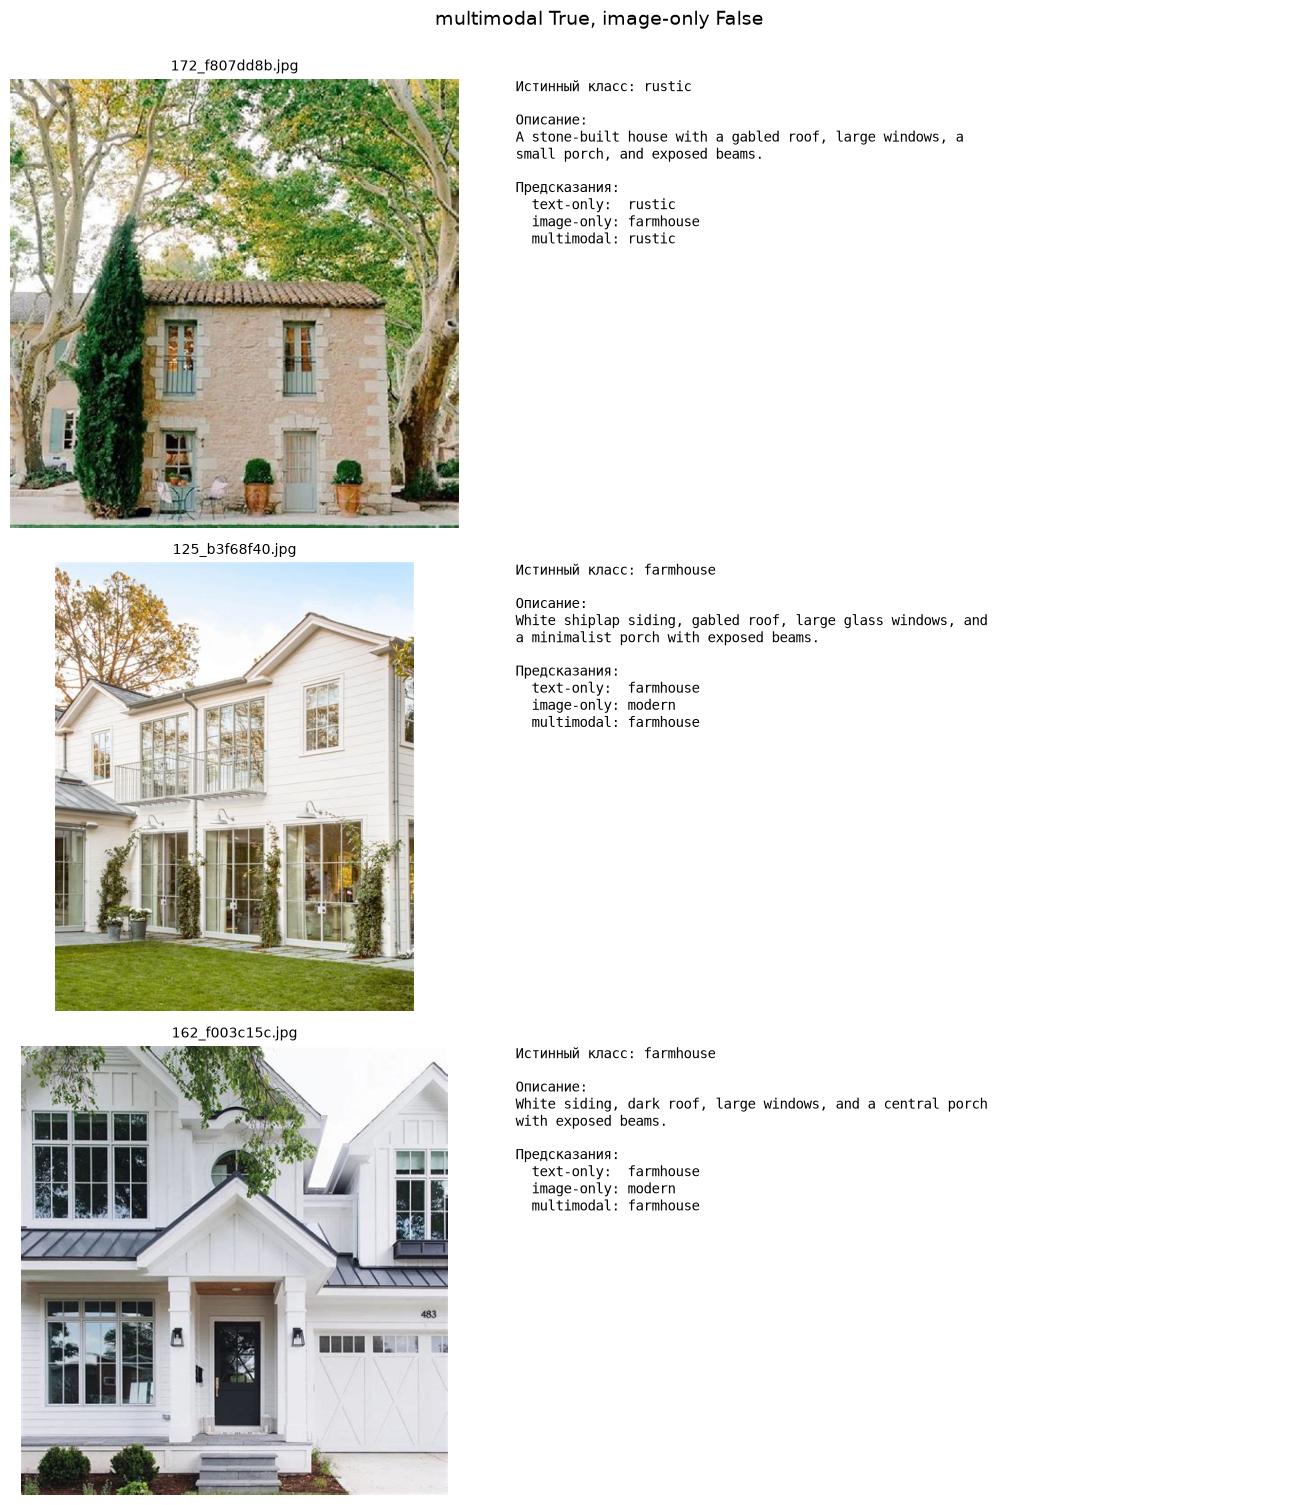

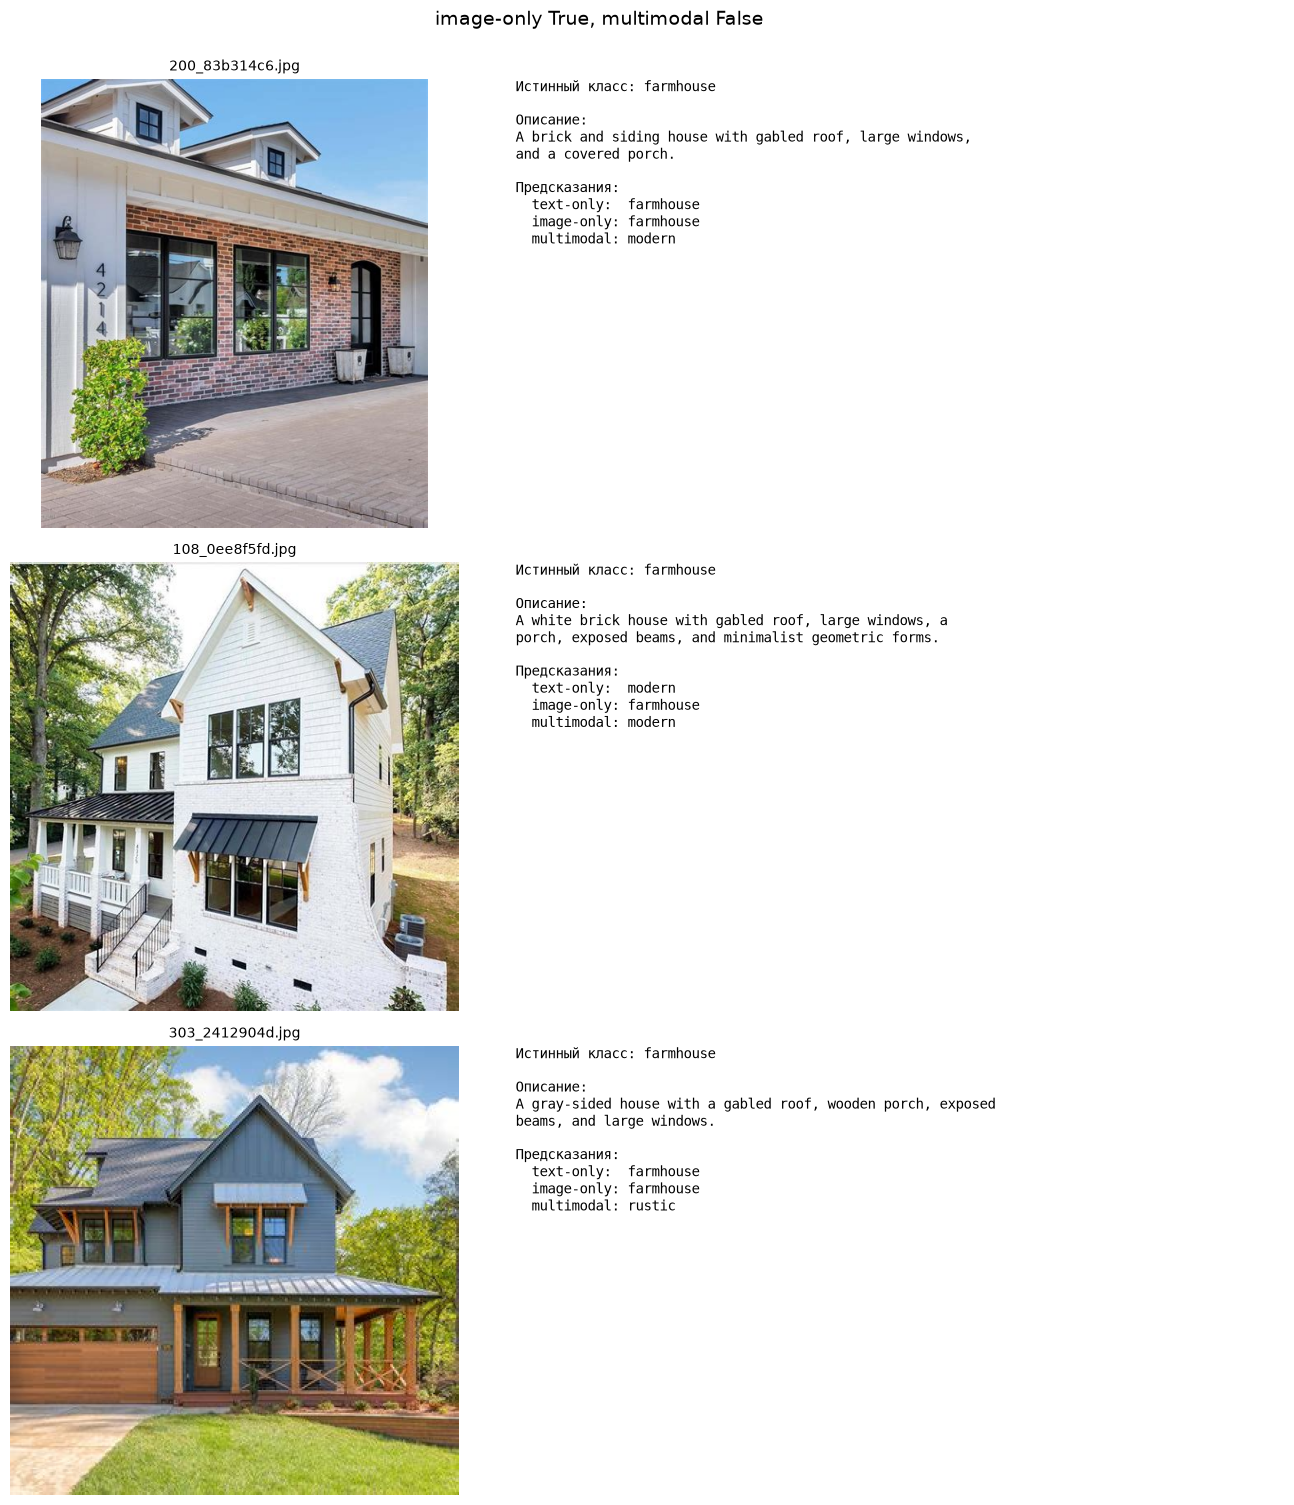

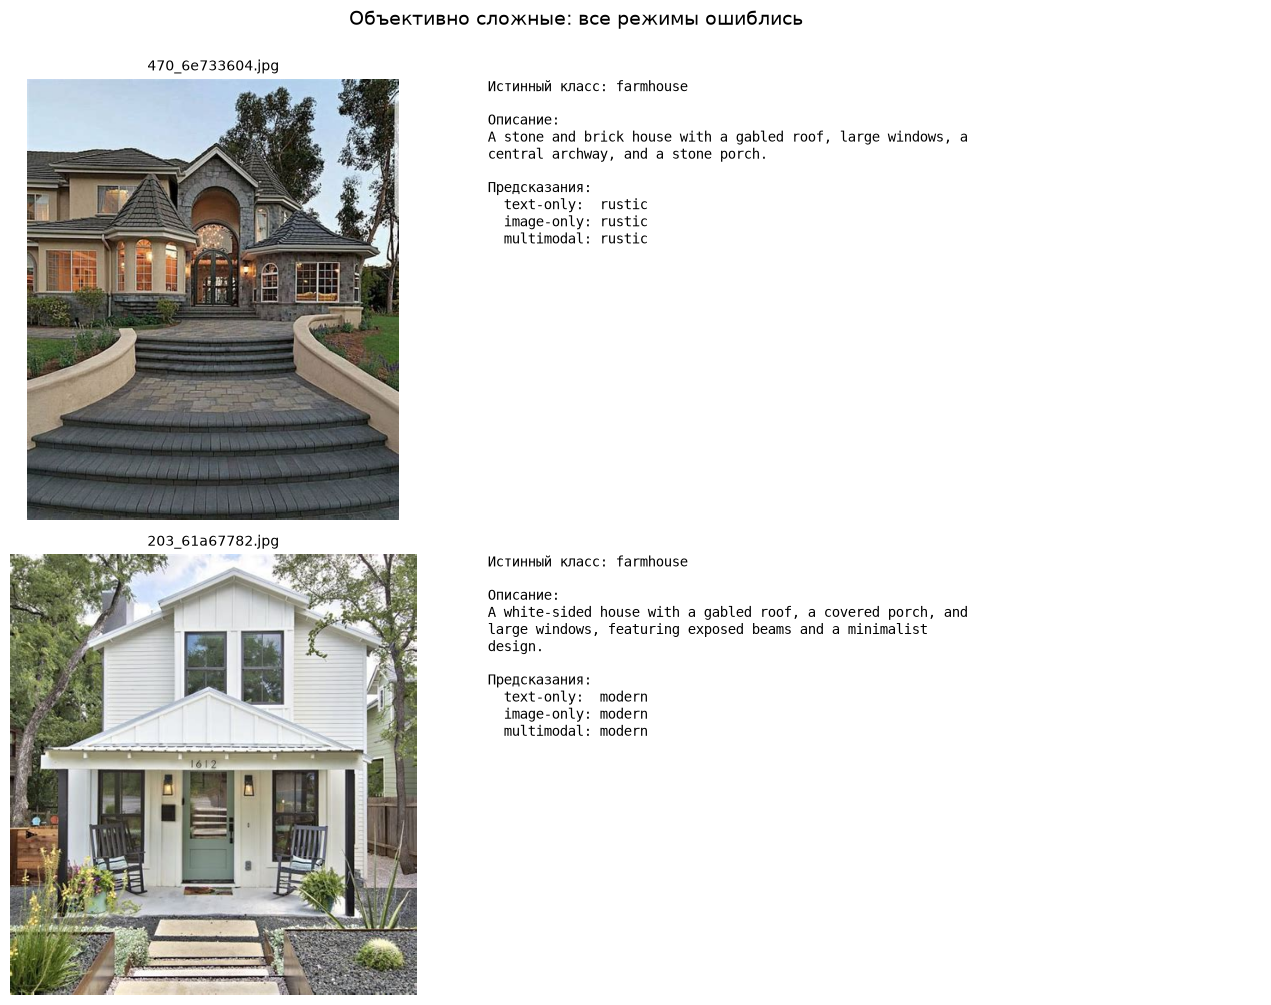

Готово: conflict_text_helps.png, conflict_image_helps.png, conflict_all_wrong.png
Сохранено: modality_conflicts.csv (8 строк)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import textwrap

IMG_DIR = "house_images/all_images/all_images"
preds = pd.read_csv("preds_best_mistral.csv")

# подтягиваем описания из best_set
best = pd.read_csv("best_set.csv")
preds = preds.merge(best[["filename", "text"]].rename(columns={"text": "description"}), on="filename", how="left")

help_text = preds[
    (preds["multimodal"] == preds["true"]) & (preds["image"] != preds["true"])
].head(3).reset_index(drop=True)

help_image = preds[
    (preds["image"] == preds["true"]) & (preds["multimodal"] != preds["true"])
].head(3).reset_index(drop=True)

all_wrong = preds[
    (preds["text"] != preds["true"]) & (preds["image"] != preds["true"]) &
    (preds["multimodal"] != preds["true"])
].head(2).reset_index(drop=True)


def show_examples(df, main_title, fname):
    n = len(df)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n),
                             gridspec_kw={"width_ratios": [1, 1.2]})
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(df.iterrows()):
        ax_img, ax_txt = axes[i]

        # слева — картинка
        img = Image.open(os.path.join(IMG_DIR, row["filename"]))
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(row["filename"], fontsize=10)

        # справа — текст с разбором
        desc = textwrap.fill(str(row["description"]), width=60)
        block = (
            f"Истинный класс: {row['true']}\n\n"
            f"Описание:\n{desc}\n\n"
            f"Предсказания:\n"
            f"  text-only:  {row['text']}\n"
            f"  image-only: {row['image']}\n"
            f"  multimodal: {row['multimodal']}"
        )
        ax_txt.text(0, 1, block, va="top", ha="left", fontsize=10,
                    family="monospace", wrap=True)
        ax_txt.axis("off")

    fig.suptitle(main_title, fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()


show_examples(help_text, "multimodal True, image-only False", "conflict_text_helps.png")
show_examples(help_image, "image-only True, multimodal False", "conflict_image_helps.png")
show_examples(all_wrong, "Объективно сложные: все режимы ошиблись", "conflict_all_wrong.png")

print("Готово: conflict_text_helps.png, conflict_image_helps.png, conflict_all_wrong.png")

conflicts = pd.concat([
    help_text.assign(type="text_helps"),
    help_image.assign(type="image_helps"),
    all_wrong.assign(type="all_wrong"),
])
conflicts.to_csv("modality_conflicts.csv", index=False)
print(f"Сохранено: modality_conflicts.csv ({len(conflicts)} строк)")

Случаев, где text-only ошибся, а multimodal угадал: 3


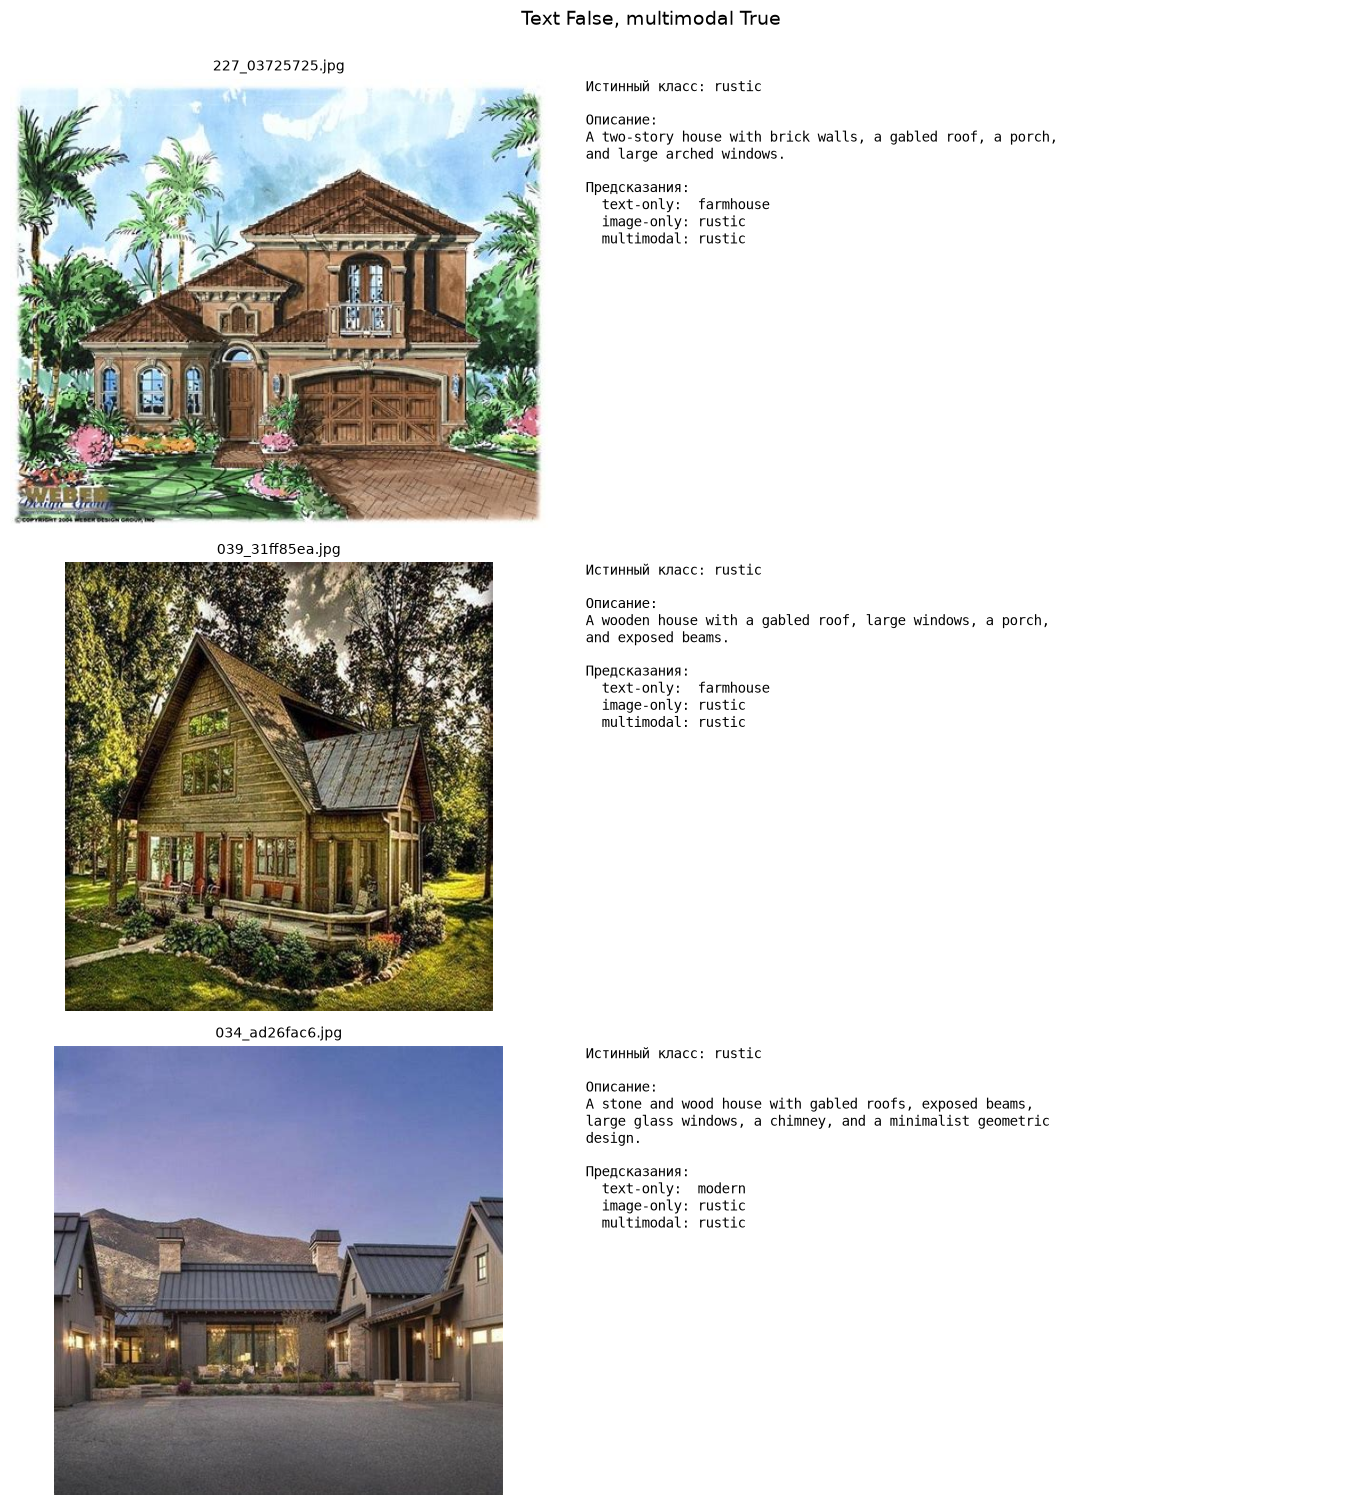

Готово: conflict_image_rescues.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import textwrap

IMG_DIR = "house_images/all_images/all_images"
preds = pd.read_csv("preds_best_mistral.csv")

# подтягиваем описания из best_set
best = pd.read_csv("best_set.csv")
preds = preds.merge(
    best[["filename", "text"]].rename(columns={"text": "description"}),
    on="filename", how="left",
)

# новая категория: text-only ошибся, multimodal угадал
help_from_image = preds[
    (preds["multimodal"] == preds["true"]) & (preds["text"] != preds["true"])
].head(3).reset_index(drop=True)

print(f"Случаев, где text-only ошибся, а multimodal угадал: {len(help_from_image)}")


def show_examples(df, main_title, fname):
    n = len(df)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n),
                             gridspec_kw={"width_ratios": [1, 1.2]})
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(df.iterrows()):
        ax_img, ax_txt = axes[i]

        img = Image.open(os.path.join(IMG_DIR, row["filename"]))
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(row["filename"], fontsize=10)

        desc = textwrap.fill(str(row["description"]), width=60)
        block = (
            f"Истинный класс: {row['true']}\n\n"
            f"Описание:\n{desc}\n\n"
            f"Предсказания:\n"
            f"  text-only:  {row['text']}\n"
            f"  image-only: {row['image']}\n"
            f"  multimodal: {row['multimodal']}"
        )
        ax_txt.text(0, 1, block, va="top", ha="left", fontsize=10,
                    family="monospace", wrap=True)
        ax_txt.axis("off")

    fig.suptitle(main_title, fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()


show_examples(
    help_from_image,
    "Text False, multimodal True",
    "conflict_image_rescues.png",
)

print("Готово: conflict_image_rescues.png")